In [1]:
import matplotlib.pyplot as plt
import numpy as np
from optims.SBS import SBS
from benchmark.ackley import Ackley
from utils.utils import create_bounds

(-5.0, 25.0)

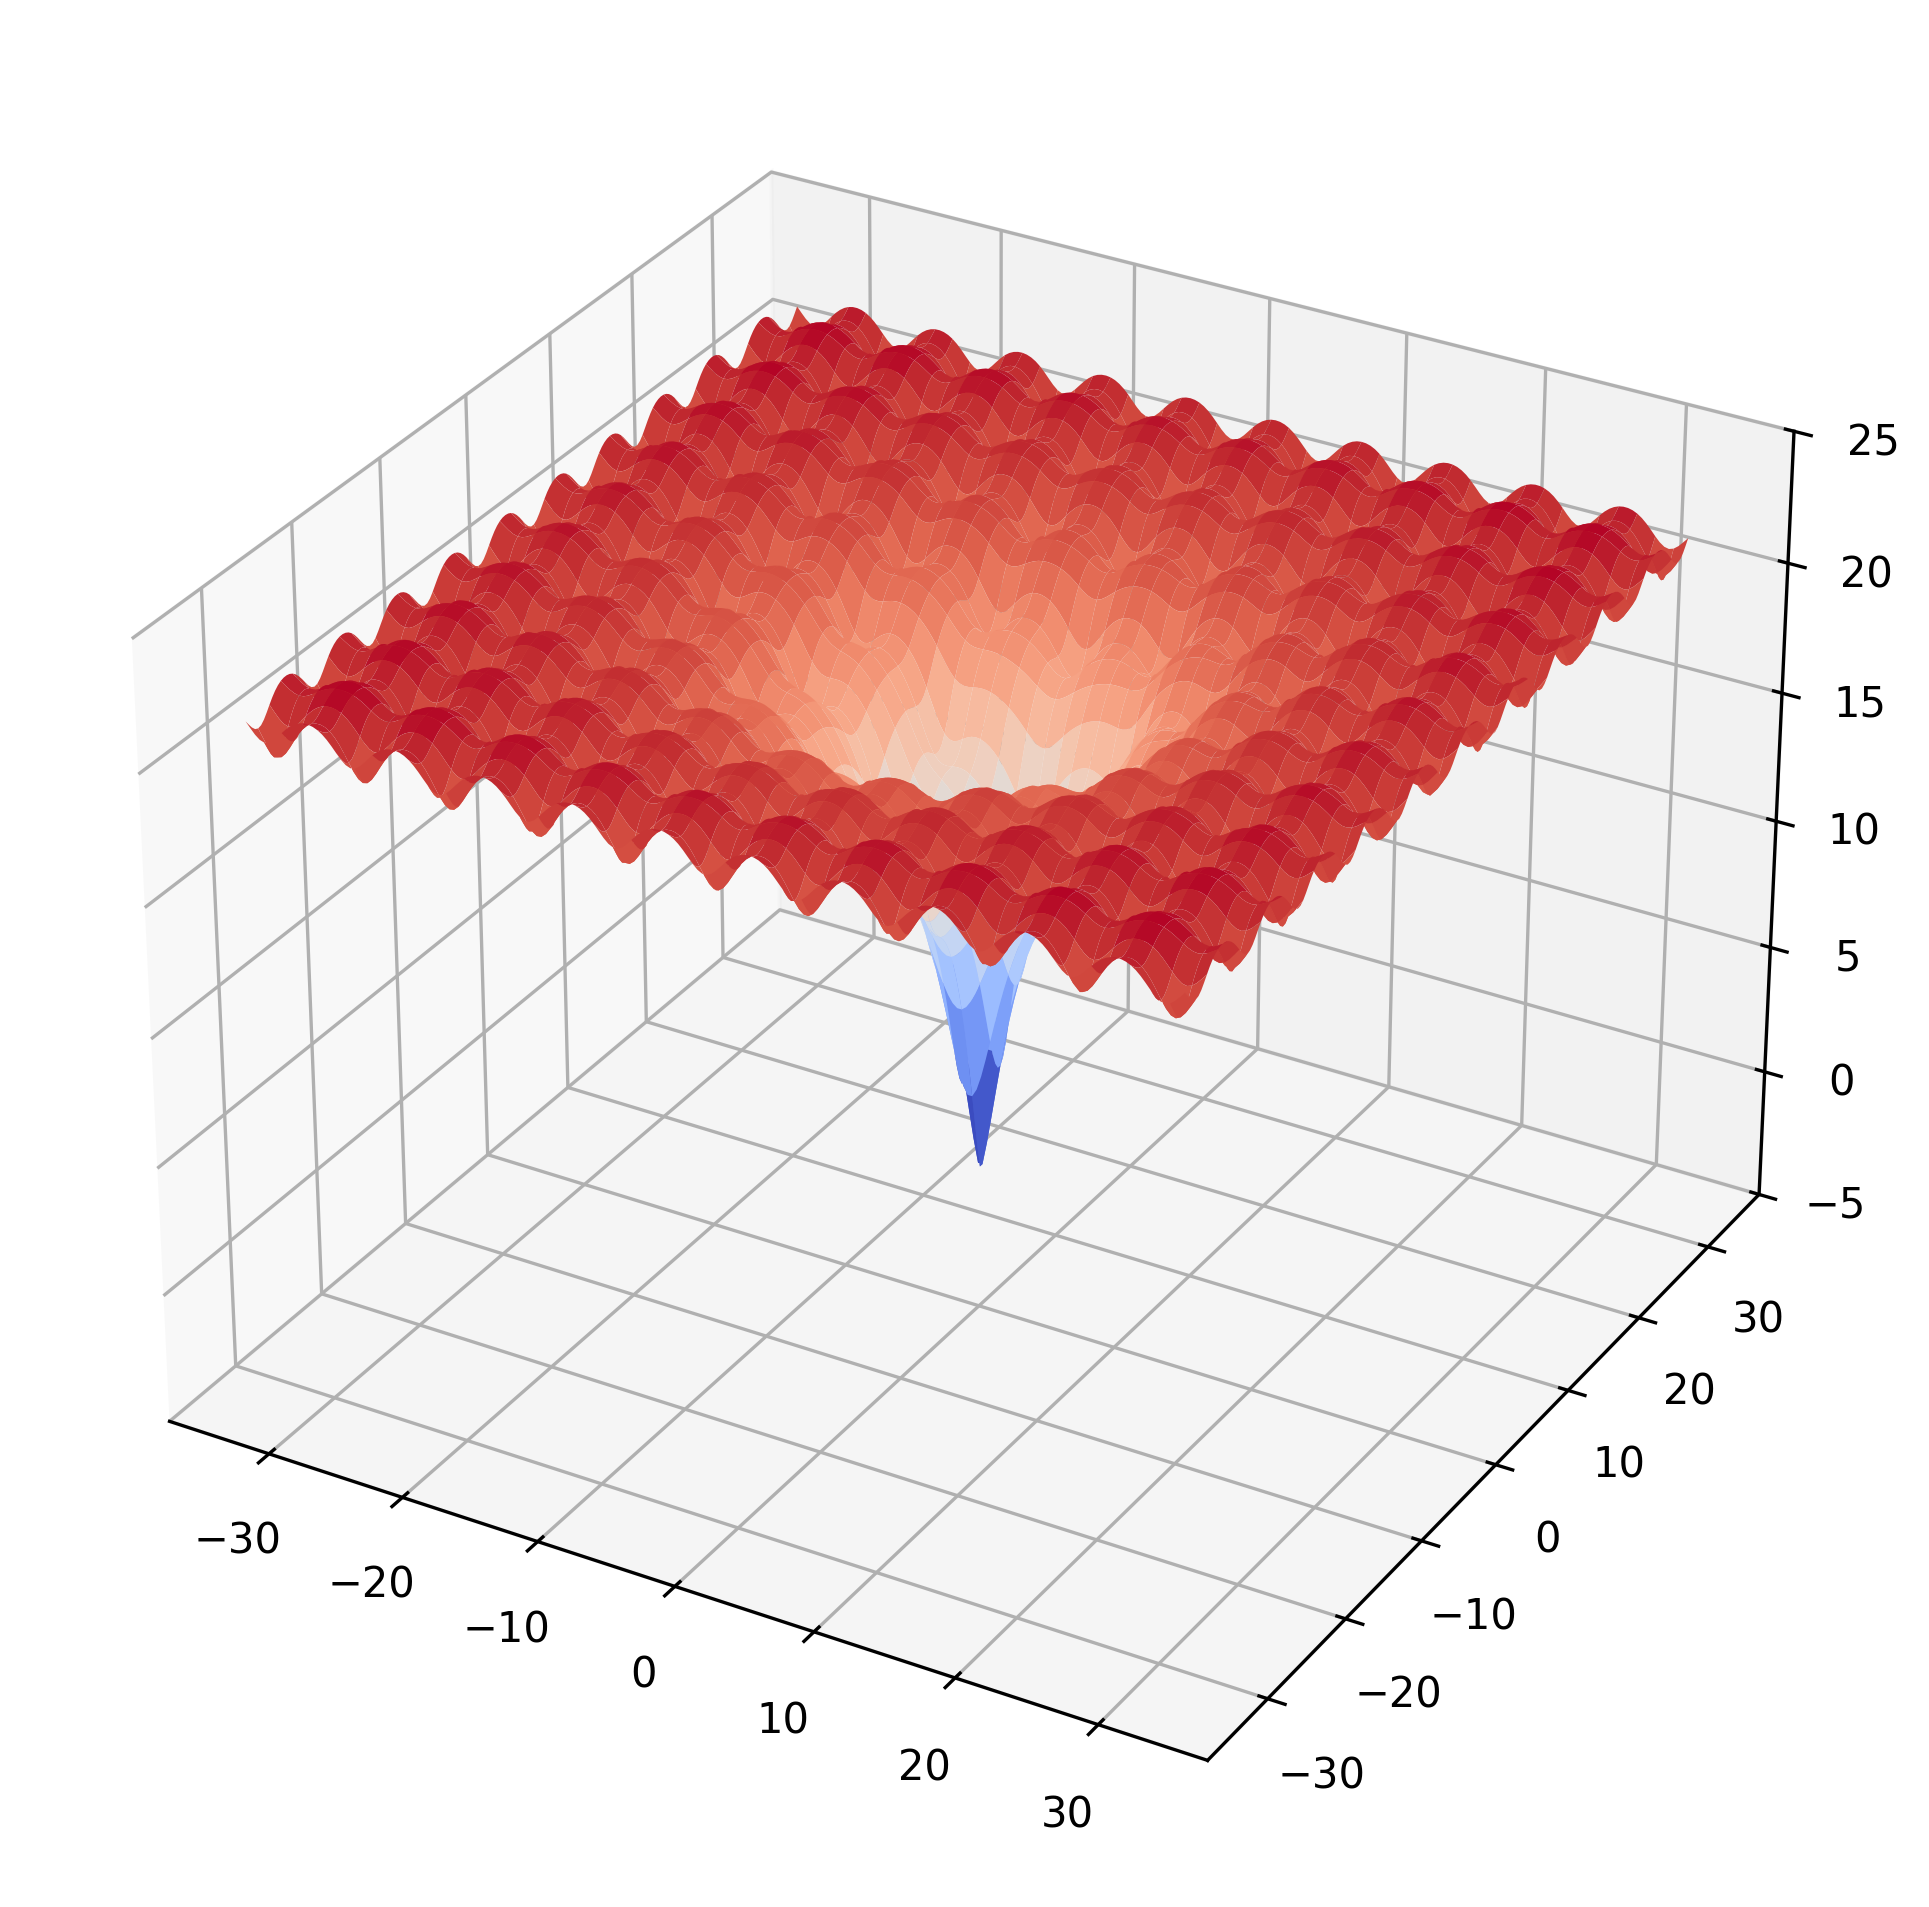

In [2]:
bounds = create_bounds(-32.768, 32.768, 2)
f = Ackley()

x = np.linspace(bounds[0][0], bounds[0][1], 200)
y = np.linspace(bounds[1][0], bounds[1][1], 200)
x, y = np.meshgrid(x, y)
z = np.array(
    [f(np.array([xi, yi])) for xi, yi in zip(np.ravel(x), np.ravel(y))]
)
Z = z.reshape(x.shape)

fig = plt.figure(figsize=(8, 8), dpi = 300)
ax = plt.axes(projection="3d", computed_zorder=False)

ax.plot_surface(
    x, y, Z, cmap="coolwarm", linewidth=0, antialiased=True, zorder=4.4
)

ax.set_zlim(-5, 25)

In [3]:
bounds2 = create_bounds(-25, 25, 2)
sbs = SBS(bounds,
            n_particles=100,
            k_iter=[10_000],
            svgd_iter=300,
            sigma=1 / 50**2,
            lr=0.2,)
res = sbs.optimize(f)
all_points = res[-2]
all_evals = res[-1]
np.array(all_points).shape, np.array(all_evals).shape

((301, 100, 2), (301, 100))

In [4]:
import matplotlib.animation as animation

def update(frame):
    eval_points = all_points[frame]
    eval_values = all_evals[frame]
    cb = ax.scatter(
        eval_points[:, 0],
        eval_points[:, 1],
        eval_values,
        c=eval_values,
        label="evaluations",
        cmap="viridis",
        zorder=4.5,
    )
    return cb


ani = animation.FuncAnimation(fig=fig, func=update, frames=len(all_points)//5, interval=100)
ani.save(filename="anim_SBS.gif", writer="pillow")